In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
## cross corr and spectrum
from statsmodels.tsa.stattools import ccf
from scipy.signal import coherence, csd
from scipy.fft import fftfreq
import statsmodels.api as sm
from scipy import signal

In [2]:
## kml to struct
from xml.etree import ElementTree as ET

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [3]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

In [4]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))

In [5]:
LON, LAT = np.meshgrid(ds.lon_rho.compute().values[0,:],ds.lat_rho.compute().values[:,0])
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [58]:
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

def zscore(x):
    return (x - x.mean()) / x.std()
    
def analyze_correlation_and_spectrum(df, x_col, y_col, lags=int, nperseg=int, xlim=500):
    """
    Plot time series, autocorrelation, cross-correlation, coherence, phase, and PSD
    between two signals in a DataFrame.

    Parameters:
        df (pd.DataFrame): DataFrame containing time series data
        x_col (str): Name of the X (reference) column
        y_col (str): Name of the Y (target) column
        lags (int): Number of lags for correlation functions
        nperseg (int): Segment length for spectral analysis
        xlim (int): Optional limit for time series plot
    """
    
    x = df[x_col]
    y = df[y_col]

    # Plot time series
    plt.figure(figsize=(12, 5))
    plt.plot(normalize(x), label=x_col, alpha=0.7)
    plt.plot(normalize(y), label=y_col, alpha=0.7)
    plt.title(f"Time Series Plot: {y_col} vs {x_col}")
    # plt.xlim(0, xlim)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Autocorrelation of x
    autocorr = sm.tsa.acf(zscore(x), nlags=lags)

    # Cross-correlations
    crosscorr_xy = sm.tsa.ccf(zscore(y), zscore(x), adjusted=False)[:lags]
    crosscorr_yx = sm.tsa.ccf(zscore(x), zscore(y), adjusted=False)[:lags]

    # top lags
    cross_corr = np.concatenate([crosscorr_xy, crosscorr_yx])
    lags_array = np.concatenate([-np.arange(lags-1, -1, -1), np.arange(1, lags)])

        #top 3 peaks
    top_idxs = np.argsort(np.abs(cross_corr))[-3:][::-1]
    print("\nTop 3 cross-correlation peaks:")
    for idx in top_idxs:
        print(f"r = {cross_corr[idx]:.3f}  |  lag = {lags_array[idx]}")
        
    # Spectral analysis
    fxx, Pxx = signal.welch(x, nperseg=nperseg)
    fyy, Pyy = signal.welch(y, nperseg=nperseg)
    fxy, Pxy = signal.csd(x, y, nperseg=nperseg)
    fcoh, Kxy = signal.coherence(x, y, nperseg=nperseg)
    
    phase = np.angle(Pxy, deg=True)
    # if y_col == 'Y4':
    #     phase= np.where(phase < 0, phase + 360, phase)
            


    # Plot
    fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

    # Cross-correlation plot
    axs[0, 0].plot(np.arange(0, lags + 1), autocorr, 'b', label=r'$\rho_{xx}$')
    axs[0, 0].plot(-np.arange(0, lags + 1), autocorr, 'b')
    axs[0, 0].plot(np.arange(0, lags), crosscorr_xy, 'r', label=fr'$\rho_{{{y_col},{x_col}}}$')
    axs[0, 0].plot(-np.arange(0, lags), crosscorr_yx, 'r')
    axs[0, 0].set_title(f'Cross-correlation between {x_col} and {y_col}')
    axs[0, 0].set_xlabel('Time lag [steps]')
    axs[0, 0].set_ylabel('Correlation')
    axs[0, 0].grid(True)
    axs[0, 0].legend()

    # Coherence using signal.coherence
    axs[0, 1].semilogx(fcoh, Kxy)
    axs[0, 1].set_title(f'Coherence ({x_col} vs {y_col})')
    axs[0, 1].set_xlabel('Frequency [1/time step]')
    axs[0, 1].set_ylabel('Coherence')
    axs[0, 1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axs[0, 1].set_ylim(0, 1)

    # Phase 
    axs[1, 0].semilogx(fxx, phase[:len(fxx)])
    axs[1, 0].set_title(f'Phase ({x_col} leads {y_col})')
    axs[1, 0].set_xlabel('Frequency [1/time step]')
    axs[1, 0].set_ylabel('Phase [degrees]')
    axs[1, 0].grid(True, which='both', linestyle='--', linewidth=0.5)
    # if y_col == 'Y4':
    #     axs[1, 0].set_ylim(0, 350)

    # Power Spectral Density
    axs[1, 1].semilogx(fxx, Pxx, label=x_col)
    axs[1, 1].semilogx(fyy, Pyy, label=y_col)
    axs[1, 1].set_title('Power Spectral Density')
    axs[1, 1].set_xlabel('Frequency [1/time step]')
    axs[1, 1].set_ylabel('Power')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()


In [56]:
# import numpy as np
# import matplotlib.pyplot as plt
# import statsmodels.api as sm
# from scipy import signal

# def normalize(data):
#     return (data - data.min()) / (data.max() - data.min())

# def zscore(x):
#     return (x - x.mean()) / x.std()

# def analyze_correlation_and_spectrum(df, x_col, y_col, lags=100, nperseg=256, xlim=500):
#     """
#     Cross-correlation convention used here:
#     R_xy[τ] = Corr(x_t, y_{t+τ})
#     τ > 0 ⇒ x leads y; τ < 0 ⇒ y leads x.
#     Phase: angle of CSD(x,y) is phase of y relative to x.
#     """
#     x = df[x_col]
#     y = df[y_col]

#     # Plot time series
#     plt.figure(figsize=(12, 5))
#     plt.plot(normalize(x), label=x_col, alpha=0.7)
#     plt.plot(normalize(y), label=y_col, alpha=0.7)
#     plt.title(f"Time Series Plot: {y_col} vs {x_col}")
#     # plt.xlim(0, xlim)
#     plt.legend()
#     plt.grid(True)
#     plt.show()

#     # Autocorrelation of x
#     autocorr = sm.tsa.acf(zscore(x), nlags=lags)

#     # Cross-correlation (symmetric, clear sign)
#     # statsmodels.ccf(a,b) = Corr(a_t, b_{t+τ}) for τ>=0
#     r_xy_pos = sm.tsa.ccf(zscore(x), zscore(y), adjusted=False)[:lags+1]   # τ = 0..+lags
#     r_yx_pos = sm.tsa.ccf(zscore(y), zscore(x), adjusted=False)[:lags+1]   # τ = 0..+lags
#     r_xy_neg = r_yx_pos[1:][::-1]  # τ = -1..-lags
#     r_xy = np.concatenate([r_xy_neg, r_xy_pos])  # length 2*lags+1
#     taus = np.arange(-lags, lags+1)

#     # Top 3 peaks (by magnitude) using the same τ axis
#     top_idxs = np.argsort(np.abs(r_xy))[-3:][::-1]
#     print("\nTop 3 cross-correlation peaks (τ>0 ⇒ {x} leads {y}):".format(x=x_col, y=y_col))
#     for idx in top_idxs:
#         print(f"r = {r_xy[idx]:.3f}  |  τ = {taus[idx]}")

#     # Spectral analysis
#     fxx, Pxx = signal.welch(x, nperseg=nperseg)
#     fyy, Pyy = signal.welch(y, nperseg=nperseg)
#     fxy, Pxy = signal.csd(x, y, nperseg=nperseg)   # CSD(X,Y)
#     fcoh, Kxy = signal.coherence(x, y, nperseg=nperseg)

#     phase = np.angle(Pxy, deg=True)  # phase of y relative to x

#     # Plot
#     fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

#     # Cross-correlation panel (keep your aspect)
#     axs[0, 0].plot(np.arange(0, lags + 1), autocorr, 'b', label=r'$\rho_{xx}$')
#     axs[0, 0].plot(-np.arange(0, lags + 1), autocorr, 'b')
#     # plot our symmetric R_xy using same styling as your red curves
#     # left side (negative τ) and right side (positive τ)
#     axs[0, 0].plot(taus[taus>=0], r_xy[taus>=0], 'r', label=fr'$R_{{{x_col},{y_col}}}(\tau)$')
#     axs[0, 0].plot(taus[taus<0],  r_xy[taus<0],  'r')
#     axs[0, 0].set_title(f'Cross-correlation between {x_col} and {y_col}  (τ>0: {x_col} leads {y_col})')
#     axs[0, 0].set_xlabel('Time lag [steps]')
#     axs[0, 0].set_ylabel('Correlation')
#     axs[0, 0].grid(True)
#     axs[0, 0].legend()

#     # Coherence
#     axs[0, 1].semilogx(fcoh, Kxy)
#     axs[0, 1].set_title(f'Coherence ({x_col} vs {y_col})')
#     axs[0, 1].set_xlabel('Frequency [1/time step]')
#     axs[0, 1].set_ylabel('Coherence')
#     axs[0, 1].grid(True, which='both', linestyle='--', linewidth=0.5)
#     axs[0, 1].set_ylim(0, 1)

#     # Phase (state clearly what it is)
#     axs[1, 0].semilogx(fxx, phase[:len(fxx)])
#     axs[1, 0].set_title(f'Phase of {y_col} relative to {x_col}  (>0: {x_col} leads; <0: {y_col} leads)')
#     axs[1, 0].set_xlabel('Frequency [1/time step]')
#     axs[1, 0].set_ylabel('Phase [degrees]')
#     axs[1, 0].grid(True, which='both', linestyle='--', linewidth=0.5)

#     # PSD
#     axs[1, 1].semilogx(fxx, Pxx, label=x_col)
#     axs[1, 1].semilogx(fyy, Pyy, label=y_col)
#     axs[1, 1].set_title('Power Spectral Density')
#     axs[1, 1].set_xlabel('Frequency [1/time step]')
#     axs[1, 1].set_ylabel('Power')
#     axs[1, 1].legend()
#     axs[1, 1].grid(True)

#     plt.tight_layout()
#     plt.show()

In [8]:
def seasonality(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

def monthly_anomaly(da, dim=('lat','lon')):
    """
    Compute monthly climatological anomalies from a DataArray.
    
    Parameters:
    - da: xarray.DataArray with dimensions including 'time' and the spatial dim to average over
    - dim: spatial dimension to average over (e.g., 'lat')
    
    Returns:
    - anomaly: xarray.DataArray with monthly anomalies (same time dimension as input)
    """
    # Step 1: mean over the spatial dimension
    da_mean = da.mean(dim=dim, skipna=True)
    
    # Step 2: compute monthly climatology (climatological mean per month)
    monthly_clim = da_mean.groupby('time.month').mean(dim='time')
    
    # Step 3: subtract climatology to get anomaly
    anomaly = da_mean.groupby('time.month') - monthly_clim

    return anomaly

### Loading Upwelling Indices

In [9]:
CHLA = xr.open_dataset('../../NHCS/hincast_1980-2015/Chlorophyll.nc',
                            chunks = {'time':1})
CHLA['time'] = pd.date_range(start="1980-01",end="2016-01",freq='M')


/tmp/ipykernel_1230398/2275464440.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  CHLA['time'] = pd.date_range(start="1980-01",end="2016-01",freq='M')


In [10]:
## generate time
time = pd.date_range(start='1980-01', end='2016-01', freq='M')
##------CUI_model
CUI = loadmat("../../NHCS/Processed/CUI_SST_index.mat")
CUI_cc = np.array(CUI['CUI_SSTi']).squeeze()
lati_cc = np.array(CUI['lati']).squeeze()
##----Ekman 
Ekman_data = loadmat("../../NHCS/Processed/EKMAN_components.mat")
Ek_pump = Ekman_data['EK_pump']
# ## Ekman transport
Ek_tr = Ekman_data['UEK']*-1

#----- Analytical Velocity
AV_data = loadmat("../../NHCS/Processed/AV.mat")
Coastal_up = loadmat("../../NHCS/Processed/Coastal_upwelling.mat")

#----- CUTI
CUTI_data = loadmat("../../NHCS/Processed/CUTI.mat")

#-------- BEUTI
BEUTI_data = loadmat("../../NHCS/Processed/BEUTI.mat")

#-------- BUI 
BUI_data = loadmat("../../NHCS/Processed/BUI.mat")

#----- CROCO wmld
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

CUI_ds = xr.DataArray(
    data=CUI_cc.T,  # numpy array of Mean_CUI
    dims=["time",'lat'],  # Dimension matches the time in CUI_MAX
    coords={"time": time,
           'lat': lati_cc},  # Ensure matching time coordinates
    name="CUI_cc"  # Name for the variable
)

/tmp/ipykernel_1230398/2426928416.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01', end='2016-01', freq='M')


In [11]:
UI_ds = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)),
        'Ekman_pump': (("time", "lat","lon"), Ek_pump.transpose(2, 1, 0)),
        'Ekman_transport':(("time", "lat","lon"), Ek_tr.transpose(2, 1, 0)),
        'AV': (("time", "lat","lon"), AV_data['W_analytical'].transpose(2, 1, 0)),
        # 'CUpwelling':(('time','lat','lon'),Coastal_up['WcMean'].transpose(2, 1, 0)),
        # 'HUI': (("time", "lat","lon"), HUI_data['HUI'].transpose(2, 1, 0)),
        'CUTI': (("time", "lat","lon"), CUTI_data['CUTI'].transpose(2, 1, 0) *-1),
        'BEUTI': (("time", "lat","lon"), BEUTI_data['BEUTI'].transpose(2, 1, 0) *-1),
        'BUI': (("time", "lat","lon"), BUI_data['BUI'].transpose(2, 1, 0)),        
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)

UI_ds = UI_ds * inshore_mask *mask_nan

In [12]:
UI_season = seasonality(UI_ds)
UI_season

<xarray.Dataset> Size: 219MB
Dimensions:          (month: 12, lat: 542, lon: 602)
Coordinates:
  * lon              (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat              (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
  * month            (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    WMLD             (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    Ekman_pump       (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    Ekman_transport  (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    AV               (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    CUTI             (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    BEUTI            (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    BUI              (month, lat, lon) float64 31MB nan nan nan ... nan nan nan

In [13]:
chl_season = seasonality(CHLA)
chl_season = chl_season.compute()

Text(0.5, 1.0, 'Chlor')

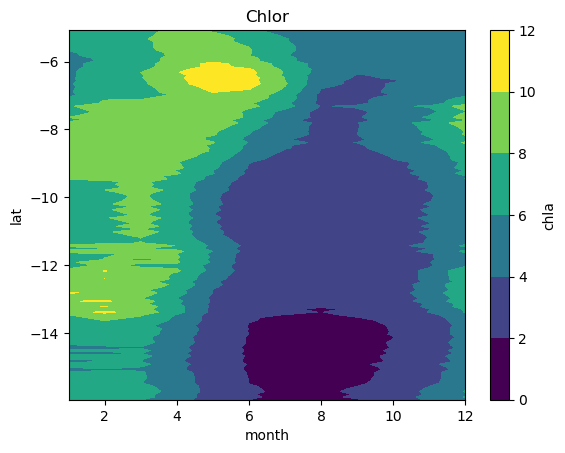

In [14]:
chl_season.chla.sel(lat=slice(-16,-5)).mean(dim='lon',skipna=True).plot.contourf(x='month',y='lat')
plt.title('Chlor')

In [15]:
UI_ds.BEUTI

<xarray.DataArray 'BEUTI' (time: 432, lat: 542, lon: 602)> Size: 1GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

### BEUTI vs Chlor

In [16]:
CHLA_=monthly_anomaly(CHLA.sel(lat=slice(-16,-5))).chla
BEUTI = monthly_anomaly(UI_ds.BEUTI.sel(lat=slice(-16,-5)))

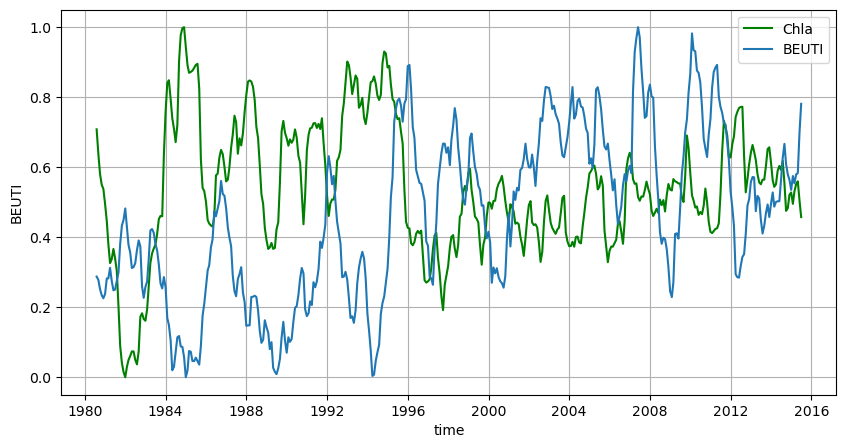

In [17]:
normalize(CHLA_.rolling(time=13,center=True).mean()).plot(figsize=(10,5),color='green',label='Chla')
normalize(BEUTI.rolling(time=13,center=True).mean()).plot(label='BEUTI')
plt.grid()
plt.legend()

In [18]:
Chlor = CHLA_.rolling(time=13,center=True).mean()
Beuti = BEUTI.rolling(time=13,center=True).mean()

# Chlor = CHLA_
# Beuti = BEUTI

B_pd = Beuti.to_series().dropna()
Chlor_pd = Chlor.to_series().dropna()

# Unir por índice (tiempo)
df = pd.concat([B_pd, Chlor_pd], axis=1)
df.columns = ['BEUTI', 'Chlor']
df

,BEUTI,Chlor
time,,
1980-07-31,-2.373973,0.424036
1980-08-31,-2.499756,0.245752
1980-09-30,-2.859126,0.100002
1980-10-31,-3.096752,0.018717
1980-11-30,-3.215422,-0.011532
...,...,...
2015-02-28,1.238825,-0.029671
2015-03-31,1.586580,0.022649
2015-04-30,1.641187,0.043958


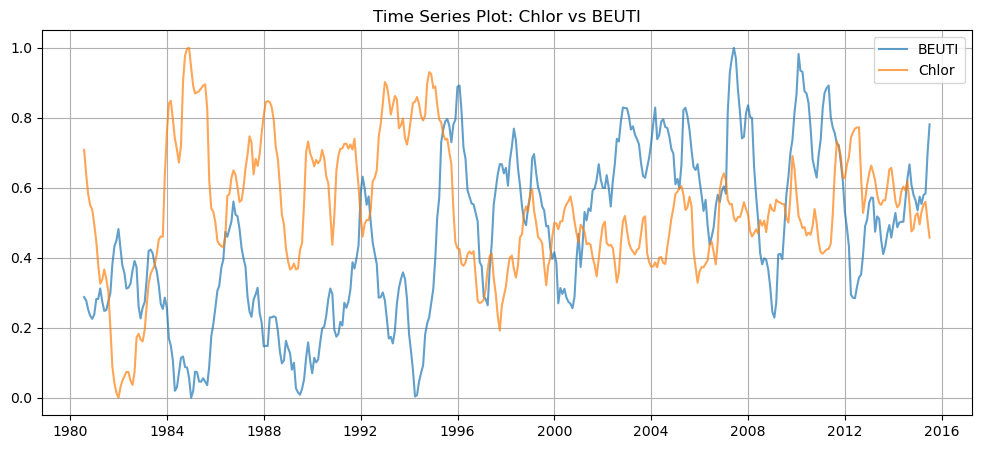


Top 3 cross-correlation peaks:
r = -0.368  |  lag = -98
r = -0.365  |  lag = 1
r = -0.365  |  lag = -99


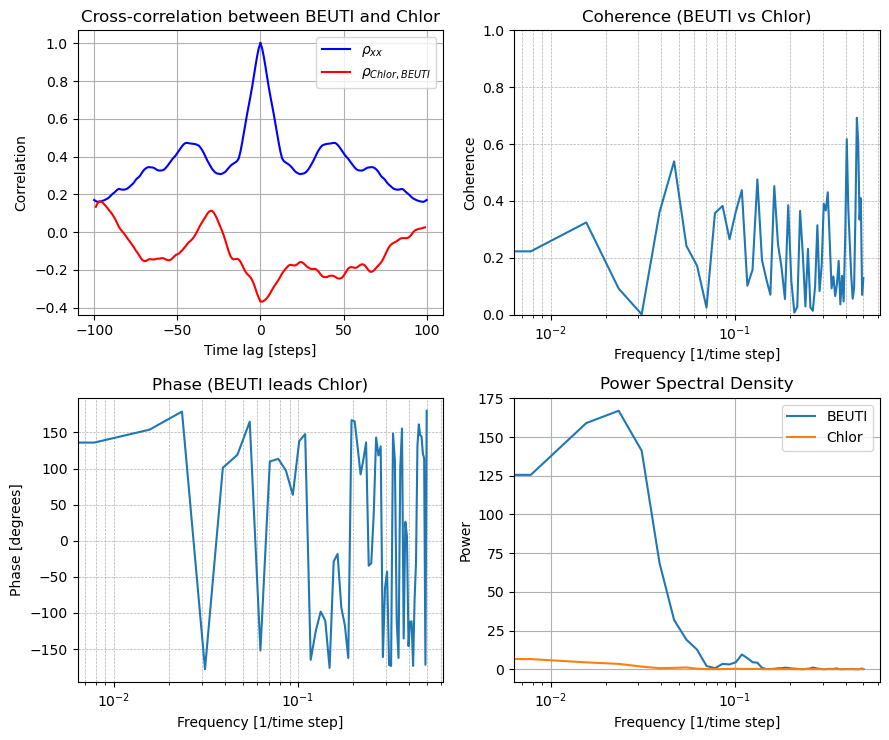

In [31]:
nperseg = 128
analyze_correlation_and_spectrum(df, 'BEUTI', 'Chlor',lags=100, nperseg=nperseg, xlim=500)

In [20]:
df.corr()

,BEUTI,Chlor
BEUTI,1.000000,-0.365187
Chlor,-0.365187,1.000000


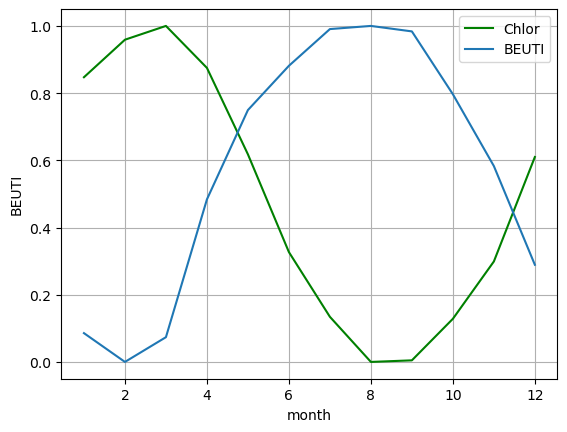

In [21]:
normalize(chl_season.chla.sel(lat=slice(-16,-5)).mean(dim=('lon','lat'),skipna=True)).plot(label='Chlor',color='green')

normalize(seasonality(UI_ds.BEUTI.sel(lat=slice(-16,-5))).mean(dim=('lon','lat'))).plot(label='BEUTI')
plt.grid()
plt.legend()

          BEUTI     Chlor
BEUTI  1.000000 -0.899289
Chlor -0.899289  1.000000


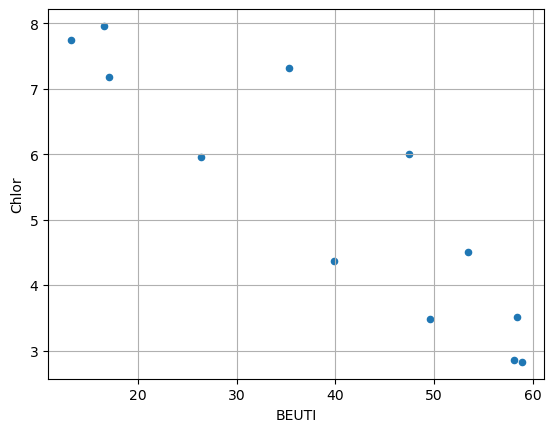

In [22]:
Chlor = chl_season.chla.sel(lat=slice(-16,-5)).mean(dim=('lon','lat'),skipna=True)
Beuti = seasonality(UI_ds.BEUTI.sel(lat=slice(-16,-5))).mean(dim=('lon','lat'))

# Chlor = CHLA_
# Beuti = BEUTI

B_pd = Beuti.to_series().dropna()
Chlor_pd = Chlor.to_series().dropna()

# Unir por índice (tiempo)
df1 = pd.concat([B_pd, Chlor_pd], axis=1)
df1.columns = ['BEUTI', 'Chlor']
df1.plot.scatter(x='BEUTI',y='Chlor')

print(df1.corr())
plt.grid()

### CUI vs Chlor

In [23]:
def monthly_anomaly2(da, dim=('lat')):
    """
    Compute monthly climatological anomalies from a DataArray.
    
    Parameters:
    - da: xarray.DataArray with dimensions including 'time' and the spatial dim to average over
    - dim: spatial dimension to average over (e.g., 'lat')
    
    Returns:
    - anomaly: xarray.DataArray with monthly anomalies (same time dimension as input)
    """
    # Step 1: mean over the spatial dimension
    da_mean = da.mean(dim=dim, skipna=True)
    
    # Step 2: compute monthly climatology (climatological mean per month)
    monthly_clim = da_mean.groupby('time.month').mean(dim='time')
    
    # Step 3: subtract climatology to get anomaly
    anomaly = da_mean.groupby('time.month') - monthly_clim

    return anomaly

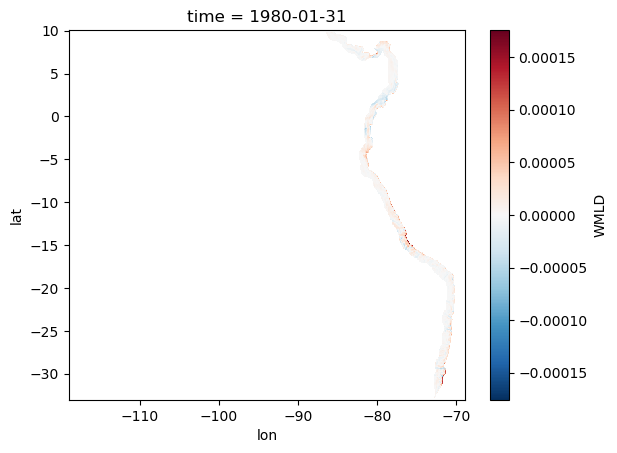

In [41]:
UI_ds.WMLD.isel(time=0).plot()

In [42]:
CHLA_=monthly_anomaly(CHLA.sel(lat=slice(-16,-5))).chla.rolling(time=13,center=True).mean()
CUI = monthly_anomaly2(CUI_ds.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()
WMLD = monthly_anomaly2(UI_ds.WMLD.sel(lat=slice(-16,-5)).mean('lon')).rolling(time=13,center=True).mean()

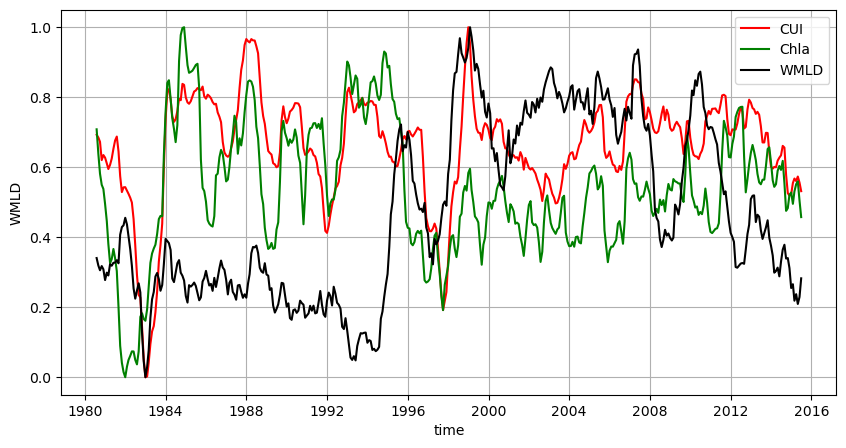

In [44]:
normalize(CUI).plot(
    figsize=(10,5),color='red',label='CUI')
normalize(CHLA_).plot(color='green',label='Chla')
normalize(WMLD).plot(color='black',label='WMLD')
plt.grid()
plt.legend()

<Axes: xlabel='CUI', ylabel='Chlor'>

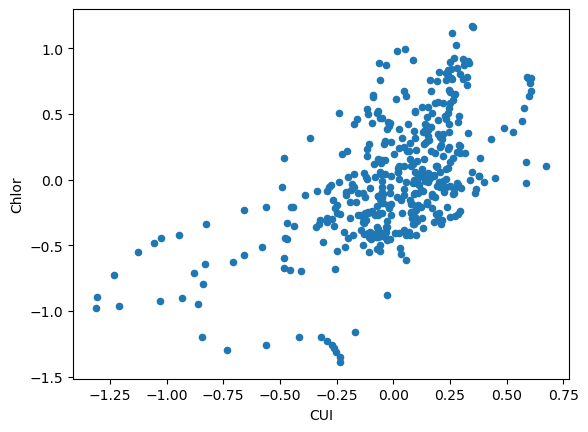

In [26]:
# Chlor = CHLA_
# Beuti = BEUTI

CUI_pd = CUI.to_series().dropna()
Chlor_pd = CHLA_.to_series().dropna()
# WMLD_pd = WMLD.to_series().dropna()

# Unir por índice (tiempo)
df2 = pd.concat([CUI_pd, Chlor_pd], axis=1)
df2.columns = ['CUI', 'Chlor']
df2.head()

df2.plot.scatter(x='CUI',y='Chlor')

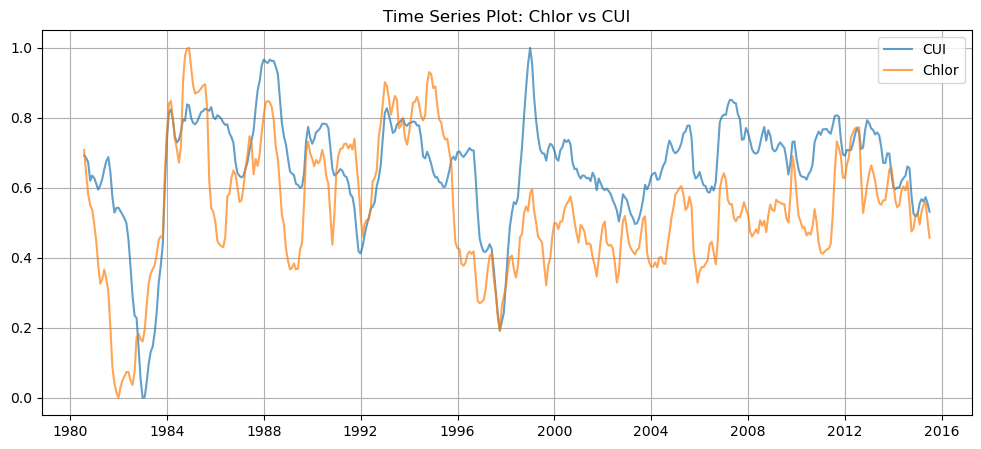


Top 3 cross-correlation peaks:
r = 0.606  |  lag = 2
r = 0.598  |  lag = 3
r = 0.597  |  lag = -99


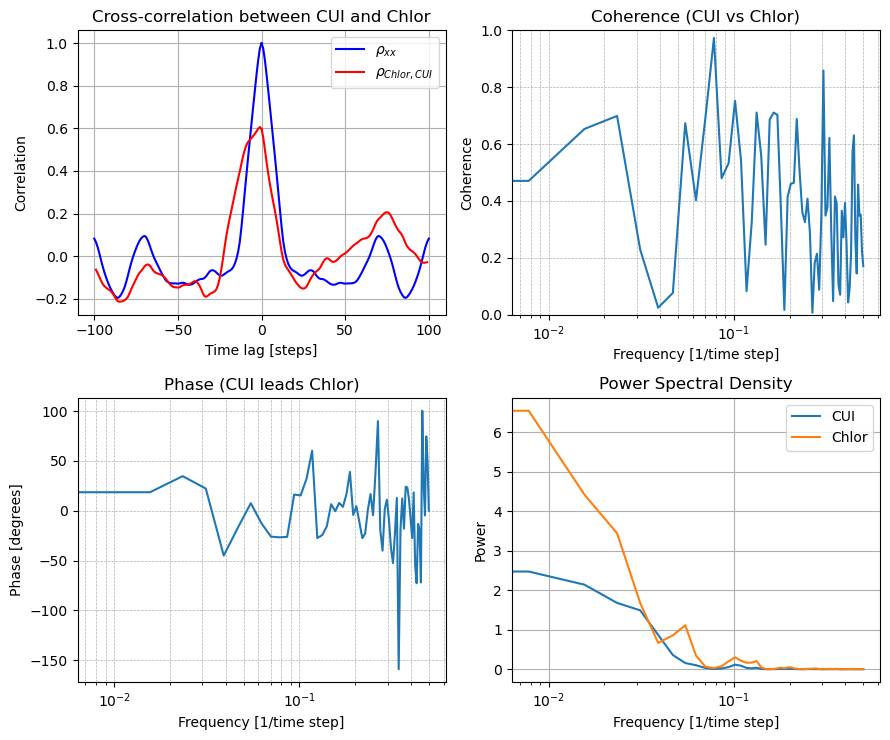

In [32]:
nperseg = 128
analyze_correlation_and_spectrum(df2, 'CUI', 'Chlor',lags=100, nperseg=nperseg, xlim=500)

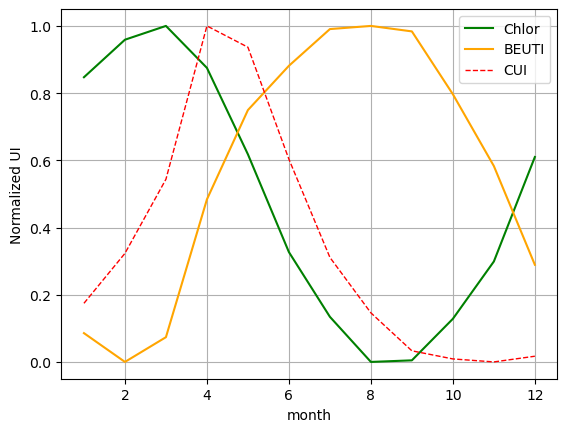

In [28]:
normalize(chl_season.chla.sel(lat=slice(-16,-5)).mean(dim=('lon','lat'),skipna=True)).plot(label='Chlor',color='green')

normalize(seasonality(UI_ds.BEUTI.sel(lat=slice(-16,-5))).mean(dim=('lon','lat'))).plot(label='BEUTI',color='orange')

normalize(seasonality(CUI_ds.sel(lat=slice(-16,-5))).mean(dim=('lat'))).plot(label='CUI',color='red',linewidth=1,linestyle='dashed')

plt.ylabel('Normalized UI')
plt.grid()
plt.legend()

<Axes: xlabel='WMLD', ylabel='Chlor'>

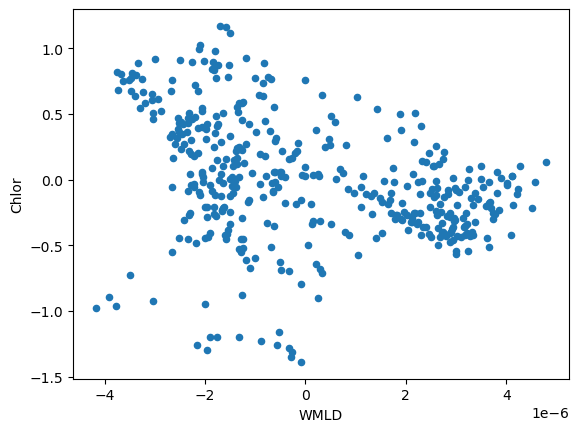

In [45]:
WMLD_pd = WMLD.to_series().dropna()

# Unir por índice (tiempo)
df3 = pd.concat([WMLD_pd, Chlor_pd], axis=1)
df3.columns = ['WMLD', 'Chlor']
df3.head()

df3.plot.scatter(x='WMLD',y='Chlor')

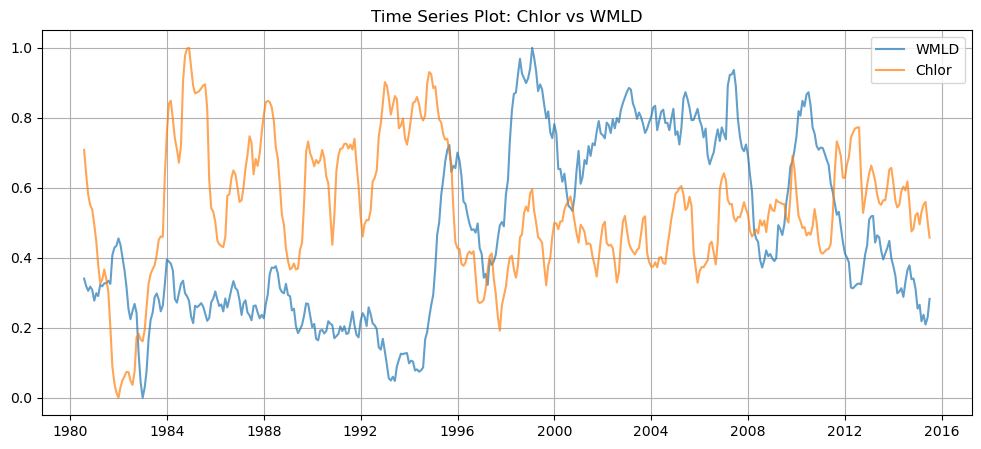


Top 3 cross-correlation peaks:
r = -0.386  |  lag = -88
r = -0.384  |  lag = -87
r = -0.383  |  lag = -89


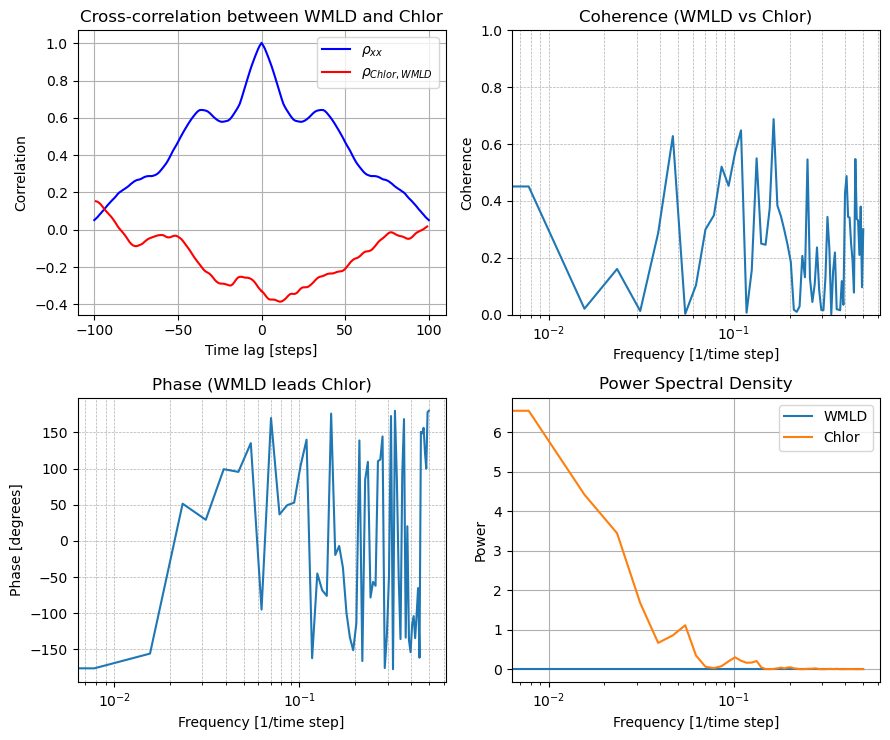

In [59]:
nperseg = 128
analyze_correlation_and_spectrum(df3, 'WMLD', 'Chlor',lags=100, nperseg=nperseg, xlim=600)